# 3D Swin Transformer SST预测 - 交互式教程

欢迎来到3D Swin Transformer的交互式学习教程！

本笔记本将带你：
1. 理解SST数据
2. 探索3D Swin Transformer模型
3. 可视化预测结果

---

## 第一部分：环境准备

In [1]:
# ============================================================
# 第一步：设置Python路径（关键！）
# ============================================================

import sys
import os
from pathlib import Path

# 获取当前notebook的路径
notebook_path = Path.cwd()
print(f"当前路径: {notebook_path}")

# 根据notebook所在位置设置项目根目录
if notebook_path.name == 'notebooks':
    # 如果notebook在notebooks/子目录
    project_root = notebook_path.parent
else:
    # 如果notebook在项目根目录
    project_root = notebook_path

print(f"项目根目录: {project_root}")

# 添加src目录到Python路径
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
    print(f"✅ 已添加src到Python路径: {src_path}")
else:
    print(f"✅ src已在Python路径中")

# ============================================================
# 第二步：导入必要的库
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import xarray as xr

# 设置中文显示（Windows可能需要）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 检查GPU可用性
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ 计算设备: {device}")
if torch.cuda.is_available():
    print(f"   GPU型号: {torch.cuda.get_device_name(0)}")
    print(f"   可用显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

当前路径: D:\QinBo\Sea-Interface-Temperature-Prodictor
项目根目录: D:\QinBo\Sea-Interface-Temperature-Prodictor
✅ 已添加src到Python路径: D:\QinBo\Sea-Interface-Temperature-Prodictor\src



✅ 计算设备: cuda
   GPU型号: NVIDIA GeForce RTX 4060 Laptop GPU
   可用显存: 8.00 GB


---

## 第二部分：探索SST数据

In [2]:
# 尝试加载SST数据
data_path = project_root / 'HadISST_sst.nc'

try:
    # 使用xarray加载数据
    ds = xr.open_dataset(data_path, decode_times=True)
    print("✅ 数据加载成功！")
    print("\n数据集信息:")
    print(ds)
    
except FileNotFoundError:
    print("❌ 错误: 找不到数据文件！")
    print("\n请按以下步骤操作:")
    print("1. 访问 https://www.metoffice.gov.uk/hadobs/hadisst/data/download.html")
    print("2. 下载 HadISST_sst.nc.gz")
    print("3. 解压并将文件放到项目根目录")
    print("\n暂时使用模拟数据进行演示...")

✅ 数据加载成功！

数据集信息:
<xarray.Dataset> Size: 485MB
Dimensions:    (time: 1872, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 15kB ...
    sst        (time, latitude, longitude) float32 485MB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    13/2/2026 converted to netcdf from pp format
    supplemen

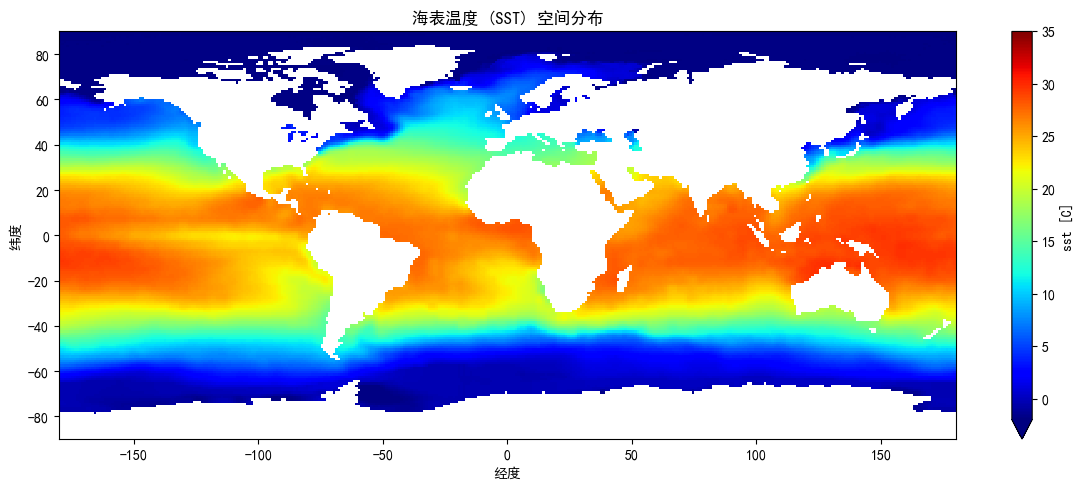

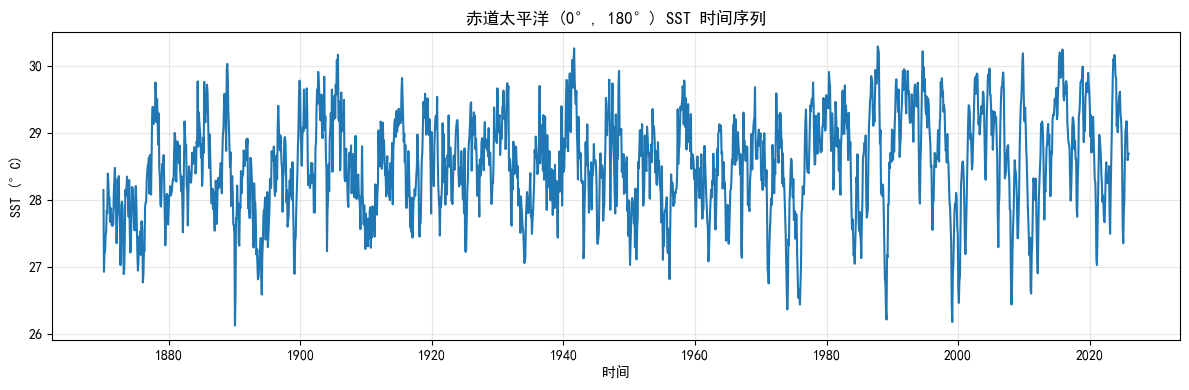

In [3]:
# 如果数据加载成功，可视化SST数据
try:
    # 提取SST数据
    sst = ds['sst']
    
    # 选择一个时间点的数据进行可视化
    sst_slice = sst.isel(time=0)  # 第一个时间点
    
    # 绘制SST空间分布
    plt.figure(figsize=(12, 5))
    sst_slice.plot(cmap='jet', vmin=-2, vmax=35)
    plt.title('海表温度 (SST) 空间分布')
    plt.xlabel('经度')
    plt.ylabel('纬度')
    plt.tight_layout()
    plt.show()
    
    # 绘制SST时间序列（某个点）
    sst_point = sst.sel(latitude=0, longitude=180, method='nearest')
    
    plt.figure(figsize=(12, 4))
    sst_point.plot()
    plt.title('赤道太平洋 (0°, 180°) SST 时间序列')
    plt.xlabel('时间')
    plt.ylabel('SST (°C)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"无法可视化真实数据: {e}")
    print("\n使用模拟数据演示...")
    
    # 生成模拟SST数据
    np.random.seed(42)
    lat = np.linspace(-90, 90, 45)
    lon = np.linspace(0, 360, 90)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    
    # 模拟SST分布（从赤道向两极递减）
    sst_simulated = 25 * np.cos(np.radians(lat_grid)) + np.random.randn(45, 90) * 2
    
    plt.figure(figsize=(12, 5))
    plt.contourf(lon, lat, sst_simulated, levels=20, cmap='jet')
    plt.colorbar(label='SST (°C)')
    plt.title('模拟SST空间分布')
    plt.xlabel('经度')
    plt.ylabel('纬度')
    plt.tight_layout()
    plt.show()

---

## 第三部分：探索3D Swin Transformer模型

In [22]:
# 导入模型（Jupyter里强制reload，避免继续使用缓存的旧模块）
import importlib
import model_3dswin

model_3dswin = importlib.reload(model_3dswin)
build_swin_3d_tiny = model_3dswin.build_swin_3d_tiny
print(f"模型代码路径: {Path(model_3dswin.__file__).resolve()}")


# 创建Tiny模型
print("正在创建3D Swin Transformer (Tiny)...")
model = build_swin_3d_tiny(
    window_size=(2, 7, 7),
    output_dim=1
)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n✓ 模型创建成功！")
print(f"  总参数量: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"  可训练参数量: {trainable_params:,}")

模型代码路径: D:\QinBo\Sea-Interface-Temperature-Prodictor\src\model_3dswin.py
正在创建3D Swin Transformer (Tiny)...

✓ 模型创建成功！
  总参数量: 27,860,143 (27.86M)
  可训练参数量: 27,860,143


In [23]:
# 测试模型前向传播
print("\n测试模型前向传播...")

# 创建模拟输入
batch_size = 2
input_months = 12
height = 56
width = 56

x = torch.randn(batch_size, 1, input_months, height, width)
print(f"输入形状: {x.shape}")

# 前向传播
model.eval()
with torch.no_grad():
    output = model(x)

print(f"输出形状: {output.shape}")
print(f"\n✓ 前向传播成功！")
print(f"  输入: {x.shape} → 输出: {output.shape}")


测试模型前向传播...
输入形状: torch.Size([2, 1, 12, 56, 56])
输出形状: torch.Size([2, 1, 1, 56, 56])

✓ 前向传播成功！
  输入: torch.Size([2, 1, 12, 56, 56]) → 输出: torch.Size([2, 1, 1, 56, 56])


In [29]:
# 可视化模型架构（可选）
print("\n模型架构摘要:")
print("="*70)

# 打印模型结构（简化版）
for name, module in model.named_children():
    num_params = sum(p.numel() for p in module.parameters())
    print(f"{name:20s} {module.__class__.__name__:30s} {num_params:12,} params")

print("="*70)
print(f"\n总计: {total_params:,} 参数")

# 如果安装了torchinfo，可以显示更详细的信息
try:
    from torchinfo import summary
    print("\n详细模型结构:")
    
    # 在CPU上做summary，避免GPU/CPU设备不一致导致的RuntimeError
    original_device = next(model.parameters()).device
    model_cpu = model.to('cpu')
    
    # 显式print字符串，避免Notebook中只生成对象但不显示文本
    stats = summary(
        model_cpu,
        input_size=(2, 1, 12, 56, 56),
        device='cpu',
        depth=4,
        verbose=0
    )
    print(stats)
    
    # 恢复模型到原设备
    model.to(original_device)

except ImportError:
    print("\n提示: 安装 torchinfo 查看更详细的模型结构")
    print("      pip install torchinfo")
except RuntimeError as e:
    print("\n⚠️ torchinfo 运行失败，已保留简化模型摘要")
    print(f"错误信息: {e}")
    print("\n建议: 先运行第8个单元做前向传播，再运行第9个单元。")


模型架构摘要:
patch_embed          PatchEmbed3D                          3,360 params
stages               ModuleList                       27,559,566 params
norm                 LayerNorm                             1,536 params
output_proj          Sequential                          295,681 params

总计: 27,860,143 参数

详细模型结构:
Layer (type:depth-idx)                             Output Shape              Param #
SwinTransformer3D                                  [2, 1, 1, 56, 56]         --
├─PatchEmbed3D: 1-1                                [2, 96, 6, 14, 14]        --
│    └─Conv3d: 2-1                                 [2, 96, 6, 14, 14]        3,168
│    └─LayerNorm: 2-2                              [2, 6, 14, 14, 96]        192
├─ModuleList: 1-2                                  --                        --
│    └─SwinTransformer3DStage: 2-3                 [2, 96, 6, 14, 14]        --
│    │    └─ModuleList: 3-1                        --                        --
│    │    │    └─SwinTrans

### 下一步做什么
1. **完整阅读文档**：
   - 打开 `README_3DSwinSST.md` 获取完整指南
   - 查看 `README_SwinTransformer.md` 了解技术细节

2. **开始训练**：
   ```bash
   # 快速测试
   python src/train.py --epochs 1 --spatial_downsample 4
   
   # 正式训练
   python src/train.py --epochs 50 --model_type tiny
   ```

3. **探索代码**：
   - `src/data_loader.py`：数据处理的完整流程
   - `src/model_3dswin.py`：模型架构的详细实现
   - `src/train.py`：训练流程的完整代码

4. **实验和改进**：
   - 尝试不同的模型大小（tiny/small/base）
   - 调整超参数（学习率、batch size等）
   - 修改输入时间长度（input_months）
   - 尝试预测多步（output_months > 1）
